# Compute the vertical profile of a global statistic

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


/home/b/b384080/.conda/envs/eekenv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 0) define functions

In [2]:
def calc_horizontal_stat(da, area_weights, stat, mask=None, dims=None,grid_cell_fractions=None):
    if stat == 'mean':
        da_stat = SpaceOperator.calc_spatial_mean(da, area_weights, mask=mask, dims=dims, grid_cell_fractions=grid_cell_fractions)
    elif stat == 'integral':
        da_stat = SpaceOperator.calc_spatial_integral(da, area_weights, mask=mask, dims=dims, grid_cell_fractions=grid_cell_fractions)
    return da_stat

def get_stat(varia,model):

    # default settings
    if varia in ['dissic','o2','thetao','so','no3']:
        stat = 'mean'
    else:
        raise Exception('statistic not yet defined for this variable.')
    
    #if varia in ['tas','tos','chlos','co2s','co2']:
    #    stat = 'mean'
    #elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cSoilFast','cSoilMedium','cSoilSlow','cVeg','cCwd','cLitter','dissic','fco2antt','intdic','epc100']:
    #    stat = 'integral'
    #elif varia in ['co2mass']:
    #    stat = None

    ## overwrite some choices
    #if model == 'GISSE2.1-G-CC2':
    #    if varia == 'co2mass':
    #        stat = 'integral'
    
    return stat

## 1) get the varias, models and runs over which to do computation

In [13]:
#stat = 'integral'#'mean'
freq_input = 'monthly'#'monthly'#'yearly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['o2']#['dissic','thetao','so','no3','o2'] #'o2']#['thetao']#['intpp','intdic']#['tos','fgco2']#['tas','npp','nbp','cSoil','cVeg','cLand','co2mass','intdic','intpp','tos','fgco2'] #'co2mass']#,'fco2antt']#,'intdic'] #['dissic']#['intpp','npp','tas','tos','fgco2','nbp','fco2antt','cLand','cVeg','cSoil','npp','co2mass',]#['co2']#['co2mass']#['cSoilFast','cSoilMedium','cSoilSlow']#['epc100','cLand','cVeg','nbp','intpp','npp']#,'fgco2',''epc100']#['epc100','fgco2','intpp','tos']#['npp','cSoil','cLand','cVeg']#['fgco2','tas']#['epc100']#['fgco2','intpp','npp','cLand']#['co2s']#['intpp','chlos','epc100']#['cLand','cVeg','cSoil','npp','co2mass','tas','tos','fgco2','nbp','fco2antt','intpp','npp','cLand','cVeg','cSoil','intdic']#['npp','cLand','fgco2','nbp','fco2antt']#'fco2antt']#['tas','nbp','fgco2','fco2antt','co2mass','tos','npp']#]#['intpp','npp','tos'] # ['fgco2','nbp','cLand','dissic','cSoil','cVeg','cLitter','cCwd']#  # 'tas',                ,'co2mass']#['fgco2']#['nbp']#['nbp','cLand'] #['nbp']#['nbp']#['fco2antt']#['cLand','cSoil','cVeg','cLitter','cCwd']#['cLitter']#'cCwd',#['cLand']#['cSoil','cVeg']#['cLitter']#['cCwd']#['cSoil','cVeg']#'cLand',#['tas','nbp','npp','tos','fgco2','intpp']
models = ['NorESM2-LM'] # ['CESM2']#['GISSE2.1-G-CC2']#['EC-Earth3-ESM-1'] #['IPSL-CM6-ESMCO2']#['GFDL-ESM2M']#['CESM2']#['UKESM1-2']#['EC-Earth3-ESM-1']#['GISSE2.1-G-CC2']#['UKESM1-2']#['GISSE2.1-G-CC2']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']##['GISSE2.1-G-CC2']#['CESM2']#['ACCESS-ESM1-5'] #['ACCESS-ESM1-5']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M']#['MIROC-ES2L'] ['IPSL-CM6-ESMCO2']#['EC-Earth3-ESM-1']#['UKESM1-2']#['IPSL-CM6-ESMCO2']#['IPSL-CM6-ESMCO2']#[]#['GISSE2.1-G-CC2']#['EC-Earth3-ESM-1']#,'UKESM1-2']#['NorESM2-LM']#['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['UKESM1-2']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M'] # ,
runs = pruns.get_run_list('tipmip_tier1')#[:1]#[:-2]#[1:]#[5:]#[1:2]#[2:]#[-1:]#[:1]#[5:]#[1:]#[:-1]#[:1]#[-1:]#[:1]#[:1]#[1:]#[-1:] #

#server='spirit'#'levante'#'spirit'#
outroot = './../01_postprocessed_data/vertical_profiles'

## 2) loop over models and runs to do the computation, plotting and saving

In [4]:
from dask.distributed import Client
client = Client(n_workers=8)
client

server = MISCgrabber.get_server()
if server == 'levante':
    port = client.scheduler_info()["services"]["dashboard"]
    prefix = os.environ.get("JUPYTERHUB_SERVICE_PREFIX", "/")
    proxy_url = f"https://jupyterhub.dkrz.de/{prefix}proxy/{port}/status"
    print(proxy_url)
else:
    print(client)


working on server levante
https://jupyterhub.dkrz.de//user/b384080/levante-spawner-advanced/proxy/8787/status


In [14]:
for varia in varias:
    for model in models:
        mgrab = MODELgrabber.get_grabber(model)
        stat = get_stat(varia,model)
        member = mgrab.get_member()

        global_stats = dict()
        for run in runs:

            if model == 'CESM2':
                print(varia)
                varia = mgrab.varia_mapper_cmor_to_model(varia)
                print(varia)
    
            domain = mgrab.get_domain(varia,freq_input)
        
            print(f'Processing data for {varia}, {model}, {run}...')
            
            # first get the dataset
            da = mgrab.get_data(varia,run,freq_input=freq_input,verbose_level=1)#,server=server)#,server=server)
            print(f'... loading {da.time.size} data points in time.')
            print(da)

            if "lev" in da.dims:
                da = da.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
            elif "olevel" in da.dims:
                da = da.chunk({"time": 12,"olevel": -1})#,"i": -1,"j": -1})
            elif "z_t" in da.dims:
                da = da.chunk({"time": 12,"z_t": -1})#,"i": -1,"j": -1})

            #if model == 'CESM2' and varia == 'TEMP':
            #    print('choosing only the shallowest layer')
            #    da = da.isel(z_t=0)#.squeeze().persist()
            #    #print(da)
        
            # =====================================================
            # HORIZONTAL STAT (on correct input)
            # =====================================================
            
            if stat is not None:
                # get the area_weights
                print(f'... getting area weights.')
                area_weights = mgrab.get_area(varia,freq_input)
                #area_weights.plot();plt.show()
                #print(area_weights.lat)
                
                # which region do i want to cover
                #print(f'... getting a regional mask.') 
                
                #if varia in ['nbp','cLand']:
                print('getting land area fraction if necessary')
                grid_cell_fractions = mgrab.get_area_fraction(varia)
                #grid_cell_fractions.plot();plt.show()
                #print(grid_cell_fractions.lat)
                #else:
                #    grid_cell_fractions = None

                print('... compute horizontal statistic')
                global_stat = calc_horizontal_stat(
                    da,   # <-- key line
                    area_weights,
                    stat,
                    mask=None,
                    dims=None,
                    grid_cell_fractions=grid_cell_fractions,
                )
            else:
                grid_cell_fractions = mgrab.get_area_fraction(varia) # not directly used, but required for writing some attributes later on
                global_stat = da_for_horiz

            # make sure that the time has uniform axis
            global_stat = TimeOperator.adjust_time_axis(global_stat) 

            # =====================================================
            # NAMING (clean + consistent)
            # =====================================================
            if model == 'CESM2':
                print(varia)
                varia = mgrab.varia_mapper_model_to_cmor(varia)
                print(varia)

            name_parts = [varia]
            name_parts.append(f"global_{stat}")
            global_stat.name = "_".join(name_parts)
            
            # update the unit
            if stat == 'integral':
                unit = f'{da.units} x m2'  
            elif stat == 'mean':
                unit = f'{da.units}'
            else:
                unit = da.units
            global_stat.attrs["units"] = unit

            if grid_cell_fractions is not None:
                global_stat.attrs["grid_cell_fractions"] = f"Calculating the global {stat} for {varia} scales coastal points by their cell fractions."
            else:
                global_stat.attrs["grid_cell_fractions"] = f"sftlf or sftof are not considered when calculating {varia} {stat}."
            
            # save the data
            save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/global_{stat}'
            os.makedirs(save_dir,exist_ok=True)
            save_string = f'{save_dir}/{varia}_{model}_{run}_{member}_global_{stat}.nc'
            print(f'... saving under {save_string}')

            global_stat = global_stat.compute()

            #print(global_stat)
            #encoding = {global_stat.name: {"dtype": "float32", "zlib": True, "complevel": 4}}
            global_stat.to_netcdf(save_string, mode="w")#,encoding=encoding)

            # keep in a local dictionary for plotting
            global_stats[run] = global_stat

            #for key in global_stats.keys():
            print(f'... plotting {run}')
            global_stats[run].plot()
            print(' ')

        plt.show()


Exception: No domain is known for the variable o2. At least not for the monthly frequency.

## Plotting the vertical profiles for the different runs

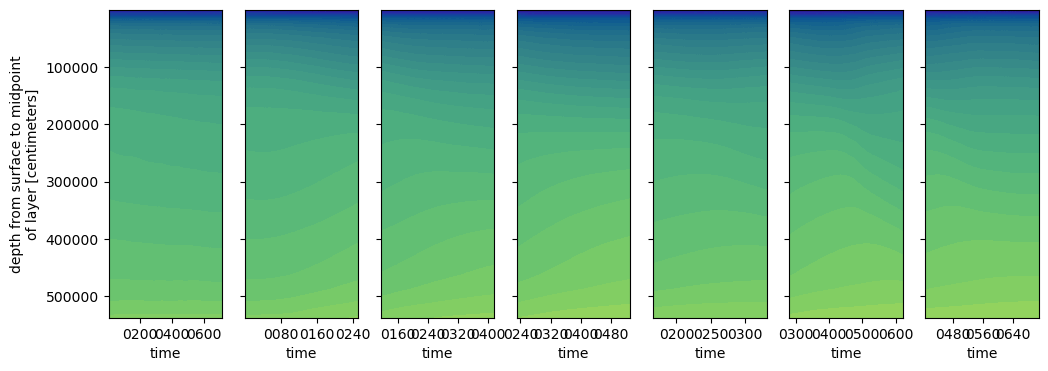

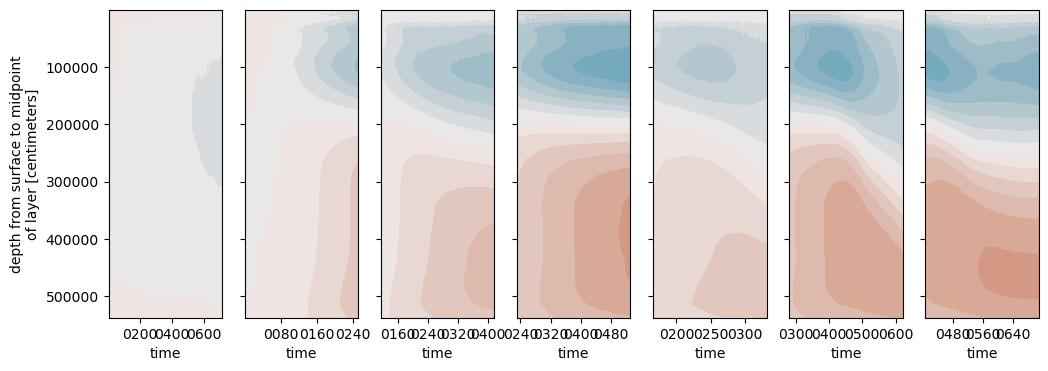

In [12]:
ref_profile = (global_stats['esm-up2p0'].isel(time=slice(0,12)).mean(dim='time'))

fig, ax = plt.subplots(1, 7, figsize=(12, 4),sharey=True)

for kdx,key in enumerate(global_stats.keys()):
    da = global_stats[key].T

    da.plot.contourf(
        ax=ax[kdx],
        x="time",
        y="z_t", #"lev",
        cmap="cmo.haline",
        vmin=0, #2.000,
        vmax=50, #2.500,
        levels=41,
        add_colorbar=False,   # don't make one automatically
    )
for adx,a in enumerate(ax):
    a.invert_yaxis()
    if adx != 0:
        a.set_ylabel('')

plt.show()

fig, ax = plt.subplots(1, 7, figsize=(12, 4),sharey=True)

for kdx,key in enumerate(global_stats.keys()):
    da = (global_stats[key] - ref_profile).T

    da.plot.contourf(
        ax=ax[kdx],
        x="time",
        y="z_t", #"lev",
        cmap="cmo.balance",
        vmin=-10,
        vmax=10,
        levels=41,
        add_colorbar=False,   # don't make one automatically
    )
for adx,a in enumerate(ax):
    a.invert_yaxis()
    if adx != 0:
        a.set_ylabel('')

plt.show()